# Project 10 - AI Agents: Tool Use & the ReAct Loop

An **agent** is an LLM that doesn't just answer - it **reasons, calls tools, looks at the result,
and repeats** until the task is done. Agentic AI is the defining trend of 2026. We build a real,
runnable agent **loop** here (with a rule-based stand-in for the LLM's decisions so it runs with no
API key), then give you the production code where a real LLM makes those decisions via function
calling.

**What you'll learn**
- The **agent loop**: Thought -> Action (use a tool) -> Observation -> repeat -> Answer (ReAct).
- **Tools / function calling**: giving the model real abilities (calculator, search, your APIs).
- **Guardrails**: max-steps and cost budgets so an agent can't loop forever or run up a bill.

## The scenario
A plain LLM can't reliably do arithmetic or look up live facts - it only predicts text. An
**agent** fixes this by letting the model *call tools*: "I need to multiply -> use the calculator
-> read the result -> continue." You'll watch an agent solve a multi-step question by chaining
two tools.

## Foundations (plain English)
- **Tool**: a normal function the agent can call (a calculator, a web search, a database query).
  Each tool has a name and a described input, so the model knows when and how to use it.
- **Function calling**: the model outputs a structured "call tool X with these arguments"; your
  code runs it and feeds the result back.
- **The ReAct loop**: **Reason** (think what to do) -> **Act** (call a tool) -> **Observe** (read
  the result) -> repeat, until the model decides it can answer.
- **Guardrails**: a max number of steps and a cost/time budget, plus a list of allowed tools, so
  the agent stays safe and cheap.

### Cell 1 - define some tools
Real Python functions the agent can call. Each does one thing well.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

def calculator(expr: str):
    return eval(expr, {"__builtins__": {}}, {})      # restricted eval (no builtins)

def letter_count(word: str):
    return len(word)

TOOLS = {"calculator": calculator, "letter_count": letter_count}
print("tools available:", list(TOOLS))

tools available: ['calculator', 'letter_count']


### Cell 2 - the 'brain' that decides the next action
In a real agent the **LLM** decides which tool to call next. To keep this notebook key-free, we
use a tiny **rule-based stand-in** that looks at what's been done so far and picks the next step.
The *loop mechanics* are exactly the same as with a real LLM - only the decision-maker changes.

In [2]:
def decide(goal, scratch):
    # returns (thought, action, argument). action='final' means we're done.
    if "product" not in scratch:
        return ("First I should compute 23 * 19.", "calculator", "23*19")
    if "letters" not in scratch:
        return ("Now I need the number of letters in 'transformer'.", "letter_count", "transformer")
    return ("I have both results; I can add them for the final answer.",
            "final", scratch["product"] + scratch["letters"])
print("decision policy ready (stands in for the LLM)")

decision policy ready (stands in for the LLM)


### Cell 3 - the agent loop (with guardrails) and a full trace
The loop runs Thought -> Action -> Observation until `decide` returns `final`, but never more than
`MAX_STEPS` times (a guardrail against infinite loops / runaway cost). We record every step so the
agent's reasoning is fully transparent.

In [3]:
def run_agent(goal, MAX_STEPS=6):
    scratch, trace = {}, []
    for step in range(1, MAX_STEPS + 1):
        thought, action, arg = decide(goal, scratch)
        if action == "final":
            trace.append((step, thought, "FINAL ANSWER", arg)); return arg, trace
        observation = TOOLS[action](arg)                 # ACT: call the tool
        scratch["product" if action == "calculator" else "letters"] = observation  # OBSERVE
        trace.append((step, thought, f"{action}('{arg}')", observation))
    return None, trace                                   # guardrail hit: stop

goal = "Compute 23 * 19, then add the number of letters in the word 'transformer'."
answer, trace = run_agent(goal)
print("GOAL:", goal, "\n")
for step, thought, action, obs in trace:
    print(f"Step {step}")
    print(f"  Thought     : {thought}")
    print(f"  Action      : {action}")
    print(f"  Observation : {obs}\n")
print("FINAL ANSWER:", answer)

GOAL: Compute 23 * 19, then add the number of letters in the word 'transformer'. 

Step 1
  Thought     : First I should compute 23 * 19.
  Action      : calculator('23*19')
  Observation : 437

Step 2
  Thought     : Now I need the number of letters in 'transformer'.
  Action      : letter_count('transformer')
  Observation : 11

Step 3
  Thought     : I have both results; I can add them for the final answer.
  Action      : FINAL ANSWER
  Observation : 448

FINAL ANSWER: 448


### Cell 4 - diagram: the ReAct loop
This is the cycle every agent runs: think, act with a tool, observe the result, and loop - until
it can give the final answer.

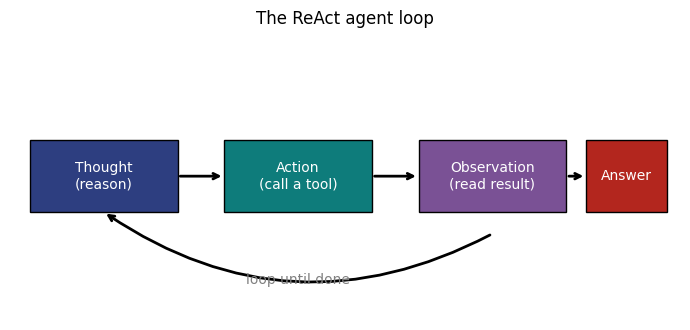

In [4]:
fig, ax = plt.subplots(figsize=(7,3.4)); ax.axis("off"); ax.set_xlim(0,10); ax.set_ylim(0,4)
def box(x,y,w,h,t,c):
    ax.add_patch(plt.Rectangle((x,y),w,h,facecolor=c,edgecolor="black"))
    ax.text(x+w/2,y+h/2,t,ha="center",va="center",color="white",fontsize=10,wrap=True)
box(0.3,1.5,2.2,1,"Thought\n(reason)","#2d3e80")
box(3.2,1.5,2.2,1,"Action\n(call a tool)","#0e7c7b")
box(6.1,1.5,2.2,1,"Observation\n(read result)","#7a5195")
ax.annotate("",(3.2,2),(2.5,2),arrowprops=dict(arrowstyle="->",lw=2))
ax.annotate("",(6.1,2),(5.4,2),arrowprops=dict(arrowstyle="->",lw=2))
ax.annotate("",(1.4,1.5),(7.2,1.2),arrowprops=dict(arrowstyle="->",lw=2,connectionstyle="arc3,rad=-0.3"))
ax.text(4.3,0.5,"loop until done",ha="center",color="grey")
box(8.6,1.5,1.2,1,"Answer","#b3261e")
ax.annotate("",(8.6,2),(8.3,2),arrowprops=dict(arrowstyle="->",lw=2))
ax.set_title("The ReAct agent loop"); plt.tight_layout(); plt.show()

### Cell 5 - diagram: the run as a timeline of tool calls
Each box is one step of the run above: which tool the agent called and what it got back. Two tool
calls, then the final answer - exactly what the trace printed.

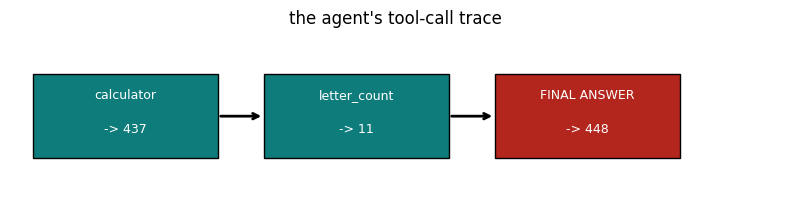

In [5]:
steps = [(a.split('(')[0], o) for (_, _, a, o) in trace]
fig, ax = plt.subplots(figsize=(8,2.2)); ax.axis("off"); ax.set_xlim(0, len(steps)*3+1); ax.set_ylim(0,2)
for i,(name,obs) in enumerate(steps):
    c = "#b3261e" if name=="FINAL ANSWER" else "#0e7c7b"
    ax.add_patch(plt.Rectangle((i*3+0.3,0.5),2.4,1,facecolor=c,edgecolor="black"))
    ax.text(i*3+1.5,1.2,name,ha="center",color="white",fontsize=9)
    ax.text(i*3+1.5,0.8,f"-> {obs}",ha="center",color="white",fontsize=9)
    if i<len(steps)-1: ax.annotate("",(i*3+3.3,1),(i*3+2.7,1),arrowprops=dict(arrowstyle="->",lw=2))
ax.set_title("the agent's tool-call trace"); plt.tight_layout(); plt.show()

## The real thing - an LLM agent with function calling (Kaggle / your machine)
Replace the rule-based `decide` with a real LLM that emits tool calls. LangGraph manages the loop,
the tools, and the guardrails.

```python
# pip install langgraph langchain langchain-openai
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

@tool
def calculator(expression: str) -> float:
    """Evaluate a math expression like '23*19'."""
    return eval(expression, {"__builtins__": {}}, {})

@tool
def web_search(query: str) -> str:
    """Search the web and return a short snippet."""
    ...   # call a search API

llm = ChatOpenAI(model="gpt-4o-mini")                 # the 'brain' that decides actions
agent = create_react_agent(llm, tools=[calculator, web_search])
result = agent.invoke({"messages": [("user", "What is 23*19 plus the population of France?")]})
print(result["messages"][-1].content)
```

**Make it production-grade:** add a step limit and cost budget, an allow-list of tools, structured
tracing of every (thought, tool, args, observation), and an eval suite that measures task success
rate over many goals (track it in W&B).

## What just happened (recap)
- An agent solved a multi-step task by **calling tools** and **looping**: Thought -> Action ->
  Observation -> repeat -> Answer (you saw the full trace and two diagrams).
- **Guardrails** (max steps) stop infinite loops; in production you also cap cost/time and allow-list tools.
- In real systems an **LLM** makes the decisions via **function calling** - the loop is identical.

## Extensions
- **Add a tool** (e.g. `word_reverse`) and a goal that needs it - extend `decide` to use it.
- **Trigger the guardrail:** set `MAX_STEPS=1` and watch the agent stop before finishing.
- **Real LLM:** wire up the LangGraph code with a model and give it an open-ended goal.
- **Next:** Project 11 coordinates *several* agents (planner, researcher, critic) on one task.

## Mini-glossary
**agent** an LLM that acts in a loop - **tool / function calling** a callable ability with a typed
input - **ReAct** Reason+Act+Observe loop - **scratchpad/memory** what the agent has learned so far
- **guardrail** max-steps / cost / allow-list - **trace** the logged sequence of steps.